# Analyzing ECG Signal with Different State of Human Activity

## Internship Project

**Student Name:** Sadiq Vaheeb Shaik  
**Roll Number:** 23691A32C4  
**Branch:** Computer Science and Engineering (Data Science)  
**College:** Madanapalle Institute of Technology & Science  

### Activities Classified
- Rest
- Walking
- Running

### Technology Used
- Python
- Google Colab
- NumPy
- Pandas
- SciPy
- Matplotlib
- Scikit-learn
- NeuroKit2
- BioSPPy

In [1]:
!pip install neurokit2 biosppy heartpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy import signal

import neurokit2 as nk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
np.random.seed(42)

sampling_rate = 250
duration = 10

activities = {
    "rest": 70,
    "walk": 100,
    "run": 140
}

signals = {}

for activity, heart_rate in activities.items():

    ecg = nk.ecg_simulate(
        duration=duration,
        sampling_rate=sampling_rate,
        heart_rate=heart_rate,
        method="ecgsyn",
        random_state=42
    )

    signals[activity] = ecg

    print(
        f"{activity.capitalize()} ECG generated: "
        f"{len(ecg)} samples"
    )

Rest ECG generated: 2500 samples
Walk ECG generated: 2500 samples
Run ECG generated: 2500 samples


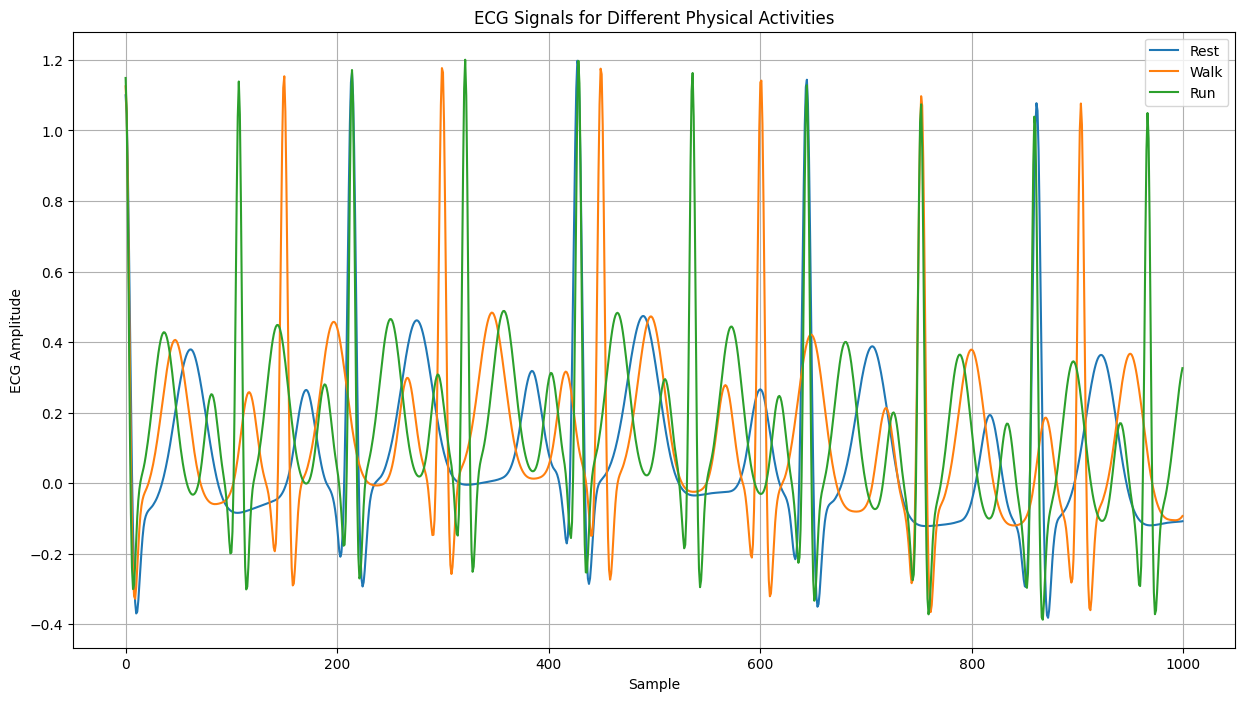

In [4]:

plt.figure(figsize=(15, 8))

for activity, ecg in signals.items():

    plt.plot(
        ecg[:1000],
        label=activity.capitalize()
    )

plt.title("ECG Signals for Different Physical Activities")
plt.xlabel("Sample")
plt.ylabel("ECG Amplitude")
plt.legend()
plt.grid()
plt.show()

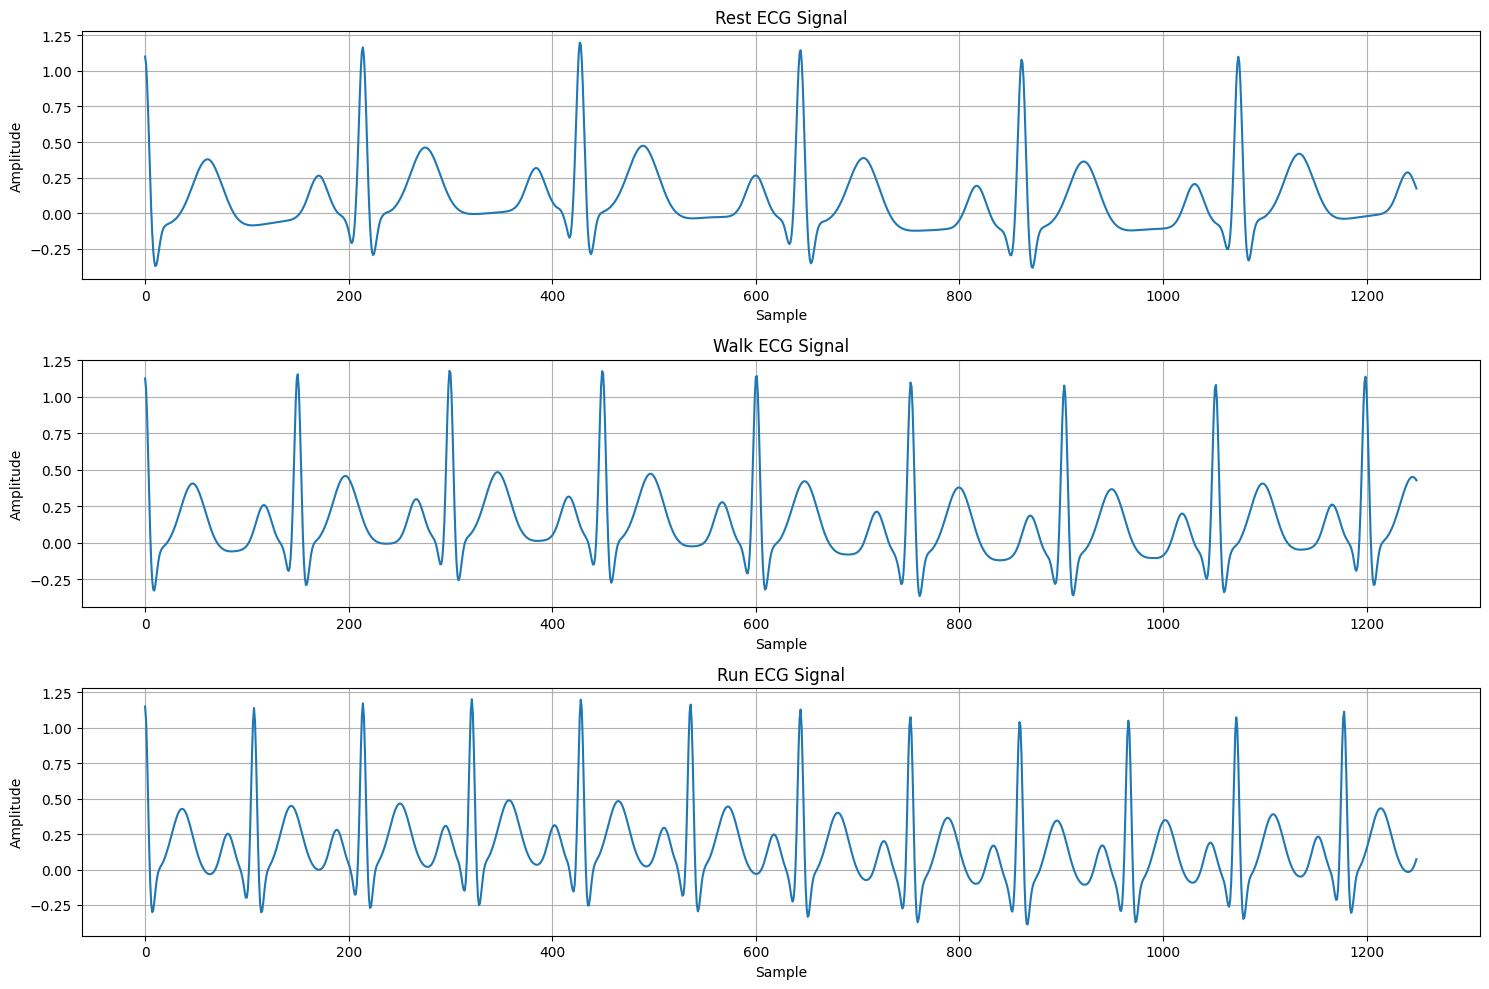

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for ax, (activity, ecg) in zip(axes, signals.items()):

    ax.plot(ecg[:1250])
    ax.set_title(f"{activity.capitalize()} ECG Signal")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")
    ax.grid()

plt.tight_layout()
plt.show()

In [6]:
processed_signals = {}

for activity, ecg in signals.items():

    cleaned_ecg = nk.ecg_clean(
        ecg,
        sampling_rate=sampling_rate,
        method="neurokit"
    )

    processed_signals[activity] = cleaned_ecg

print("ECG preprocessing completed.")

ECG preprocessing completed.


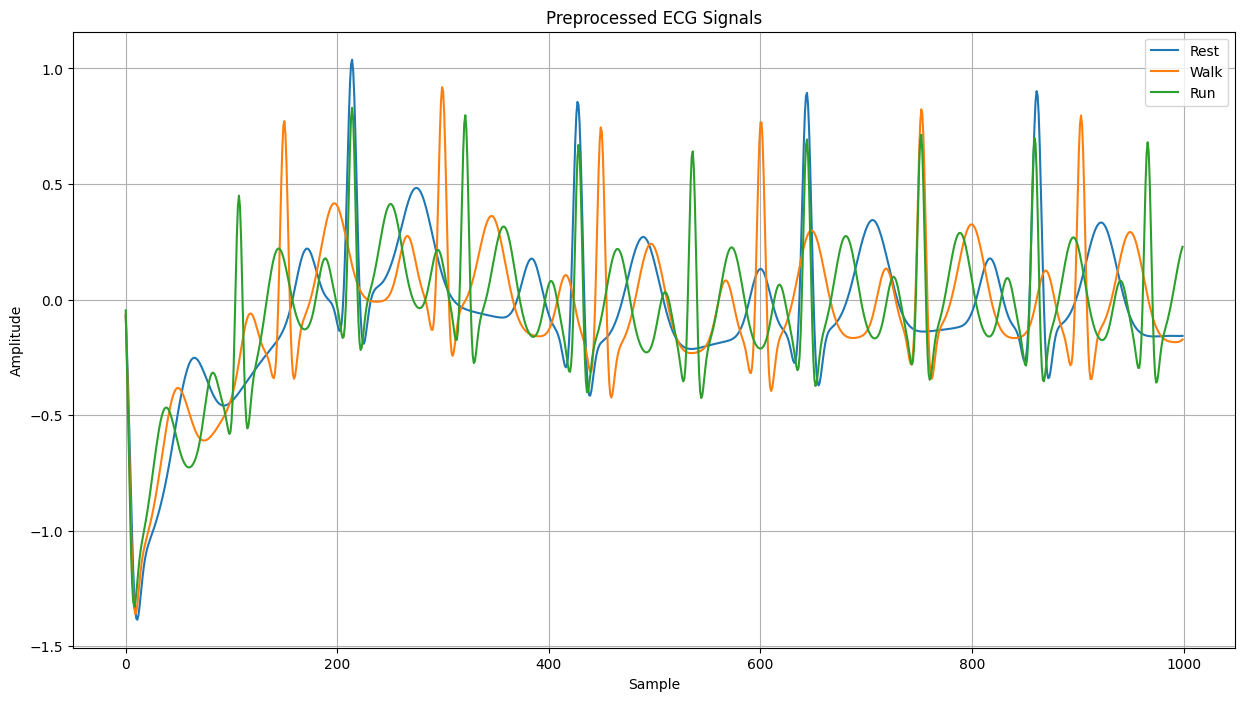

In [7]:
plt.figure(figsize=(15, 8))

for activity, ecg in processed_signals.items():

    plt.plot(
        ecg[:1000],
        label=activity.capitalize()
    )

plt.title("Preprocessed ECG Signals")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()

In [8]:
peak_data = {}

for activity, ecg in processed_signals.items():

    _, info = nk.ecg_peaks(
        ecg,
        sampling_rate=sampling_rate
    )

    r_peaks = info["ECG_R_Peaks"]

    peak_data[activity] = r_peaks

    print(
        f"{activity.capitalize()}: "
        f"{len(r_peaks)} R-peaks detected"
    )

Rest: 11 R-peaks detected
Walk: 16 R-peaks detected
Run: 23 R-peaks detected


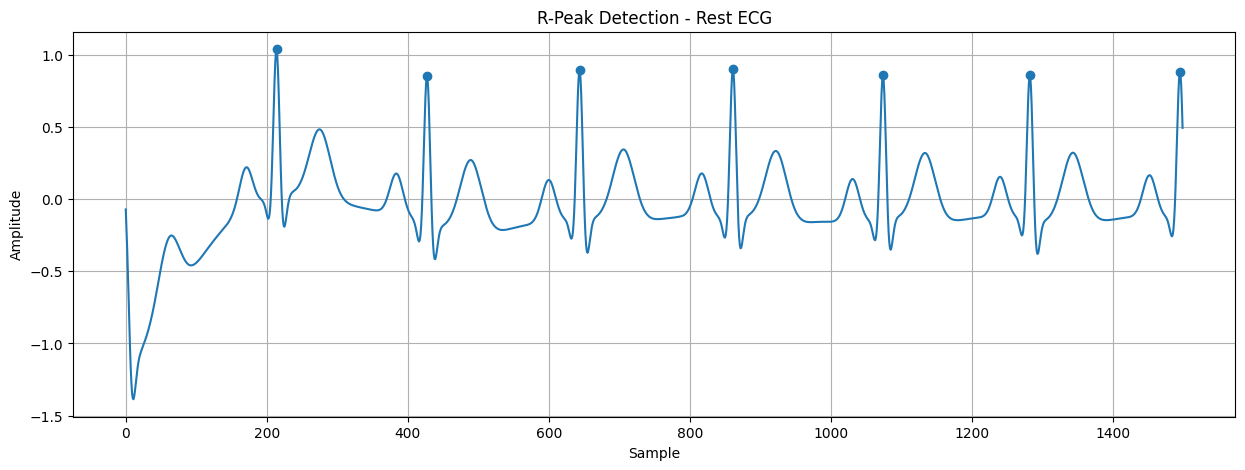

In [9]:
activity = "rest"

ecg = processed_signals[activity]
r_peaks = peak_data[activity]

plt.figure(figsize=(15, 5))

plt.plot(ecg[:1500])

valid_peaks = r_peaks[r_peaks < 1500]

plt.scatter(
    valid_peaks,
    ecg[valid_peaks]
)

plt.title("R-Peak Detection - Rest ECG")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [10]:
feature_rows = []

for activity, ecg in processed_signals.items():

    signals_df, info = nk.ecg_process(
        ecg,
        sampling_rate=sampling_rate
    )

    rate = signals_df["ECG_Rate"]

    r_peaks = info["ECG_R_Peaks"]

    rr_intervals = np.diff(r_peaks) / sampling_rate

    feature_rows.append({
        "Activity": activity,
        "Mean_HR": rate.mean(),
        "Std_HR": rate.std(),
        "Mean_RR": rr_intervals.mean(),
        "Std_RR": rr_intervals.std(),
        "RPeak_Count": len(r_peaks),
        "Signal_Mean": np.mean(ecg),
        "Signal_Std": np.std(ecg),
        "Signal_Min": np.min(ecg),
        "Signal_Max": np.max(ecg)
    })

features_df = pd.DataFrame(feature_rows)

features_df

,Activity,Mean_HR,Std_HR,Mean_RR,Std_RR,RPeak_Count,Signal_Mean,Signal_Std,Signal_Min,Signal_Max
0,rest,70.189576,1.017493,0.855200,0.013948,11,-0.022324,0.261632,-1.386144,1.037949
1,walk,100.147146,1.090927,0.599200,0.007035,16,-0.021712,0.260509,-1.361653,0.919508
2,run,140.082162,1.098512,0.428364,0.003600,23,-0.020934,0.256055,-1.329225,0.829859


In [11]:
np.random.seed(42)

dataset_rows = []

samples_per_activity = 30

for activity, base_hr in activities.items():

    for sample_id in range(samples_per_activity):

        heart_rate = np.random.normal(
            base_hr,
            3 if activity == "rest"
            else 8 if activity == "walk"
            else 12
        )

        ecg = nk.ecg_simulate(
            duration=10,
            sampling_rate=sampling_rate,
            heart_rate=heart_rate,
            method="ecgsyn",
            random_state=sample_id
        )

        cleaned = nk.ecg_clean(
            ecg,
            sampling_rate=sampling_rate
        )

        signals_df, info = nk.ecg_process(
            cleaned,
            sampling_rate=sampling_rate
        )

        rate = signals_df["ECG_Rate"]

        r_peaks = info["ECG_R_Peaks"]

        if len(r_peaks) > 1:

            rr = np.diff(r_peaks) / sampling_rate

            dataset_rows.append({
                "Activity": activity,
                "Mean_HR": rate.mean(),
                "Std_HR": rate.std(),
                "Mean_RR": rr.mean(),
                "Std_RR": rr.std(),
                "RPeak_Count": len(r_peaks),
                "Signal_Mean": cleaned.mean(),
                "Signal_Std": cleaned.std(),
                "Signal_Min": cleaned.min(),
                "Signal_Max": cleaned.max()
            })

dataset = pd.DataFrame(dataset_rows)

print("Dataset created successfully!")
print("Number of samples:", len(dataset))

dataset.head()

Dataset created successfully!
Number of samples: 90


,Activity,Mean_HR,Std_HR,Mean_RR,Std_RR,RPeak_Count,Signal_Mean,Signal_Std,Signal_Min,Signal_Max
0,rest,72.198044,2.792521,0.825091,0.047790,12,-0.021726,0.256206,-1.338280,0.983890
1,rest,69.790763,0.967723,0.860000,0.013856,11,-0.021762,0.256021,-1.363445,1.015914
2,rest,71.926608,0.773277,0.834400,0.010613,11,-0.022877,0.274185,-1.334711,0.979652
3,rest,74.650504,0.691828,0.803636,0.008434,12,-0.017474,0.207495,-1.090141,0.782442
4,rest,69.206942,0.827728,0.866800,0.012007,11,-0.021218,0.253740,-1.336131,1.017623


In [12]:
print(dataset.shape)

(90, 10)


In [13]:
dataset["Activity"].value_counts()

,count
Activity,
rest,30
walk,30
run,30


In [14]:
dataset.isnull().sum()

,0
Activity,0
Mean_HR,0
Std_HR,0
Mean_RR,0
Std_RR,0
RPeak_Count,0
Signal_Mean,0
Signal_Std,0
Signal_Min,0
Signal_Max,0


In [15]:
dataset.to_csv(
    "ECG_Activity_Feature_Dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


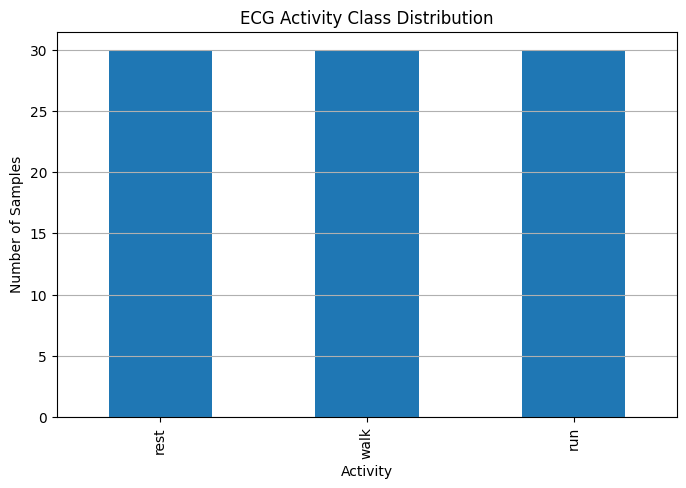

In [16]:
dataset["Activity"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("ECG Activity Class Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.grid(axis="y")
plt.show()

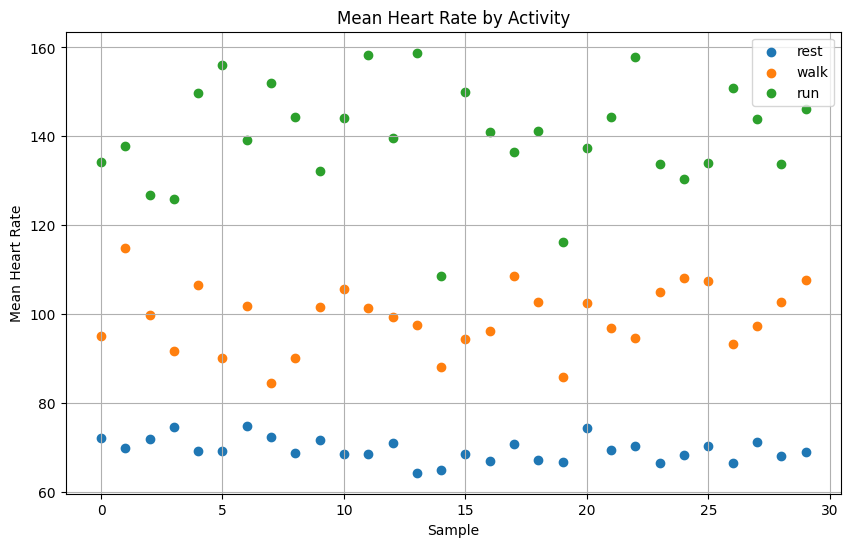

In [17]:
plt.figure(figsize=(10, 6))

for activity in dataset["Activity"].unique():

    subset = dataset[
        dataset["Activity"] == activity
    ]

    plt.scatter(
        range(len(subset)),
        subset["Mean_HR"],
        label=activity
    )

plt.title("Mean Heart Rate by Activity")
plt.xlabel("Sample")
plt.ylabel("Mean Heart Rate")
plt.legend()
plt.grid()
plt.show()

In [18]:
X = dataset.drop(
    columns=["Activity"]
)

y = dataset["Activity"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 72
Testing samples: 18


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [21]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

Logistic Regression Accuracy: 0.8888888888888888


In [22]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(
    X_train,
    y_train
)

tree_pred = decision_tree.predict(
    X_test
)

tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print(
    "Decision Tree Accuracy:",
    tree_accuracy
)

Decision Tree Accuracy: 0.8888888888888888


In [23]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

rf_pred = random_forest.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.9444444444444444


In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.888889
1,Decision Tree,0.888889
2,Random Forest,0.944444


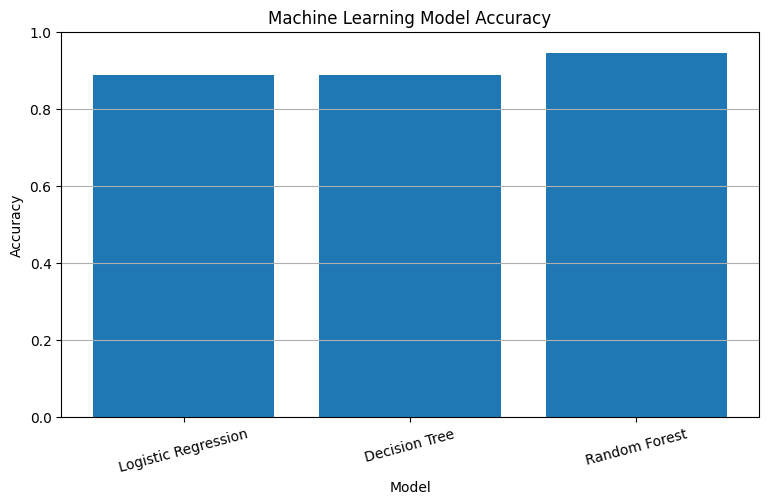

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Machine Learning Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis="y")

plt.show()

In [26]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         6
         run       1.00      0.83      0.91         6
        walk       0.86      1.00      0.92         6

    accuracy                           0.94        18
   macro avg       0.95      0.94      0.94        18
weighted avg       0.95      0.94      0.94        18



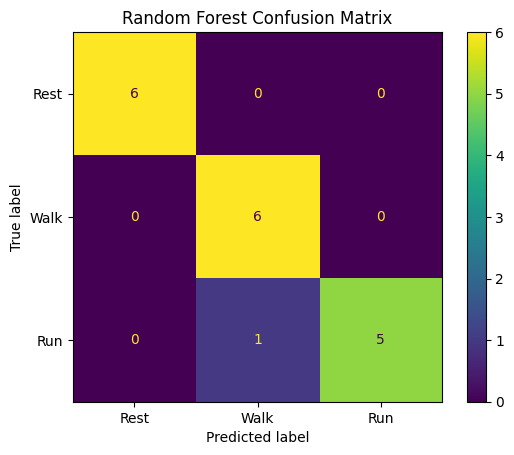

In [27]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["rest", "walk", "run"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rest", "Walk", "Run"]
)

disp.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Mean_HR,0.296320
2,Mean_RR,0.290734
4,RPeak_Count,0.226101
3,Std_RR,0.098387
8,Signal_Max,0.048855
6,Signal_Std,0.019982
7,Signal_Min,0.013668
1,Std_HR,0.003931
5,Signal_Mean,0.002021


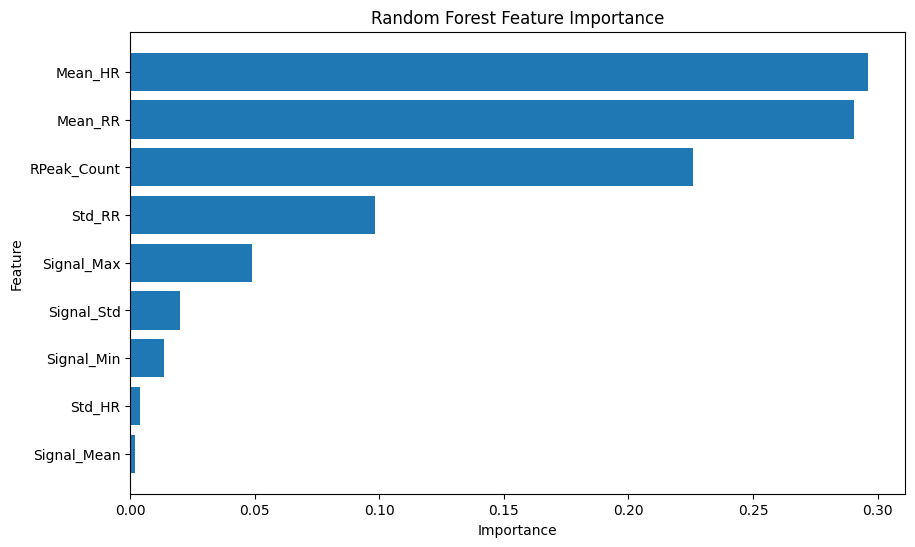

In [29]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.show()

In [30]:
test_heart_rate = 105

test_ecg = nk.ecg_simulate(
    duration=10,
    sampling_rate=sampling_rate,
    heart_rate=test_heart_rate,
    method="ecgsyn",
    random_state=100
)

test_cleaned = nk.ecg_clean(
    test_ecg,
    sampling_rate=sampling_rate
)

test_signals, test_info = nk.ecg_process(
    test_cleaned,
    sampling_rate=sampling_rate
)

test_rate = test_signals["ECG_Rate"]

test_peaks = test_info["ECG_R_Peaks"]

test_rr = np.diff(test_peaks) / sampling_rate

test_features = pd.DataFrame([{
    "Mean_HR": test_rate.mean(),
    "Std_HR": test_rate.std(),
    "Mean_RR": test_rr.mean(),
    "Std_RR": test_rr.std(),
    "RPeak_Count": len(test_peaks),
    "Signal_Mean": test_cleaned.mean(),
    "Signal_Std": test_cleaned.std(),
    "Signal_Min": test_cleaned.min(),
    "Signal_Max": test_cleaned.max()
}])

prediction = random_forest.predict(
    test_features
)

print("Predicted Activity:", prediction[0])

Predicted Activity: walk


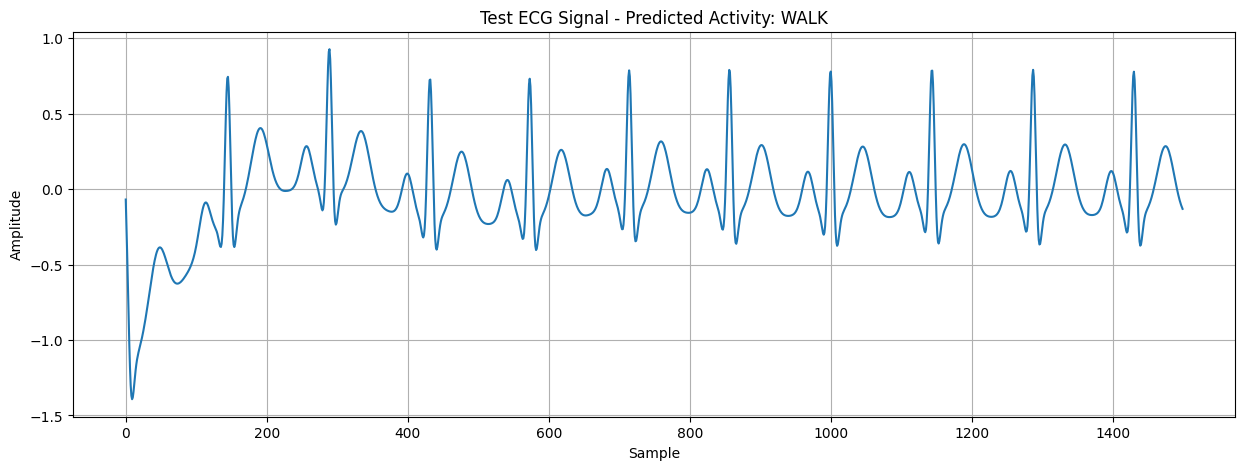

In [31]:
plt.figure(figsize=(15, 5))

plt.plot(test_cleaned[:1500])

plt.title(
    f"Test ECG Signal - Predicted Activity: {prediction[0].upper()}"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

In [32]:
import joblib

joblib.dump(
    random_forest,
    "ECG_Activity_RandomForest_Model.pkl"
)

joblib.dump(
    scaler,
    "ECG_Activity_Scaler.pkl"
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
